#### In this notebook, we'll load and take an initial look into the data

In [87]:
# Importing packages and loading data
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns # for heatmap, KDE overlaid histogram
import statsmodels.tsa.stattools as stattools # for ADF and PACF calculations
import statsmodels.graphics.tsaplots as tsaplots #for ACF and PACF plots
import statsmodels.tsa.seasonal as seasonal # for seasonal decomposition

# connect to the database
conn = sqlite3.connect("../data/aqi.db")

# load cleaned data
df = pd.read_sql("""
    SELECT city, timestamp, value, is_imputed, is_outlier_flag
    FROM cleaned_readings
    ORDER BY city, timestamp
""", conn)

conn.close()

# convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(f"total rows: {len(df)}")
print(f"date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"cities: {df['city'].unique()}")
print(f"\n{df.groupby('city')['value'].describe().round(2)}")

total rows: 6786
date range: 2026-03-30 00:00:00 to 2026-07-02 05:00:00
cities: <StringArray>
['Chicago', 'Los Angeles', 'San Jose']
Length: 3, dtype: str

              count   mean   std  min   25%   50%    75%   max
city                                                          
Chicago      2262.0   9.90  5.64  0.0   6.0   8.9  12.30  47.4
Los Angeles  2262.0  17.12  7.51  3.5  11.7  16.3  21.50  47.7
San Jose     2262.0   9.34  4.34  1.2   6.0   9.0  11.88  29.7


In [88]:
# check what's actually in raw_readings
conn = sqlite3.connect("../data/aqi.db")

raw_check = pd.read_sql("""
    SELECT city, 
           COUNT(*) as rows,
           MIN(timestamp) as earliest,
           MAX(timestamp) as latest
    FROM raw_readings
    GROUP BY city
""", conn)

conn.close()
print(raw_check)

          city  rows                    earliest                      latest
0      Chicago  2262  2026-03-30 00:00:00.000000  2026-07-02 05:00:00.000000
1  Los Angeles  2262  2026-03-30 00:00:00.000000  2026-07-02 05:00:00.000000
2     San Jose  2262  2026-03-30 00:00:00.000000  2026-07-02 05:00:00.000000


In [89]:
import requests

# test how far back Open-Meteo actually gives us data
resp = requests.get(
    "https://air-quality-api.open-meteo.com/v1/air-quality",
    params={
        "latitude":  37.34,
        "longitude": -121.89,
        "hourly":    "pm2_5",
        "timezone":  "America/Los_Angeles",
        "past_days": 90,
    }
)

data = resp.json()
times = data["hourly"]["time"]
print(f"first timestamp: {times[0]}")
print(f"last timestamp:  {times[-1]}")
print(f"total hours returned: {len(times)}")

first timestamp: 2026-04-04T00:00
last timestamp:  2026-07-07T23:00
total hours returned: 2280


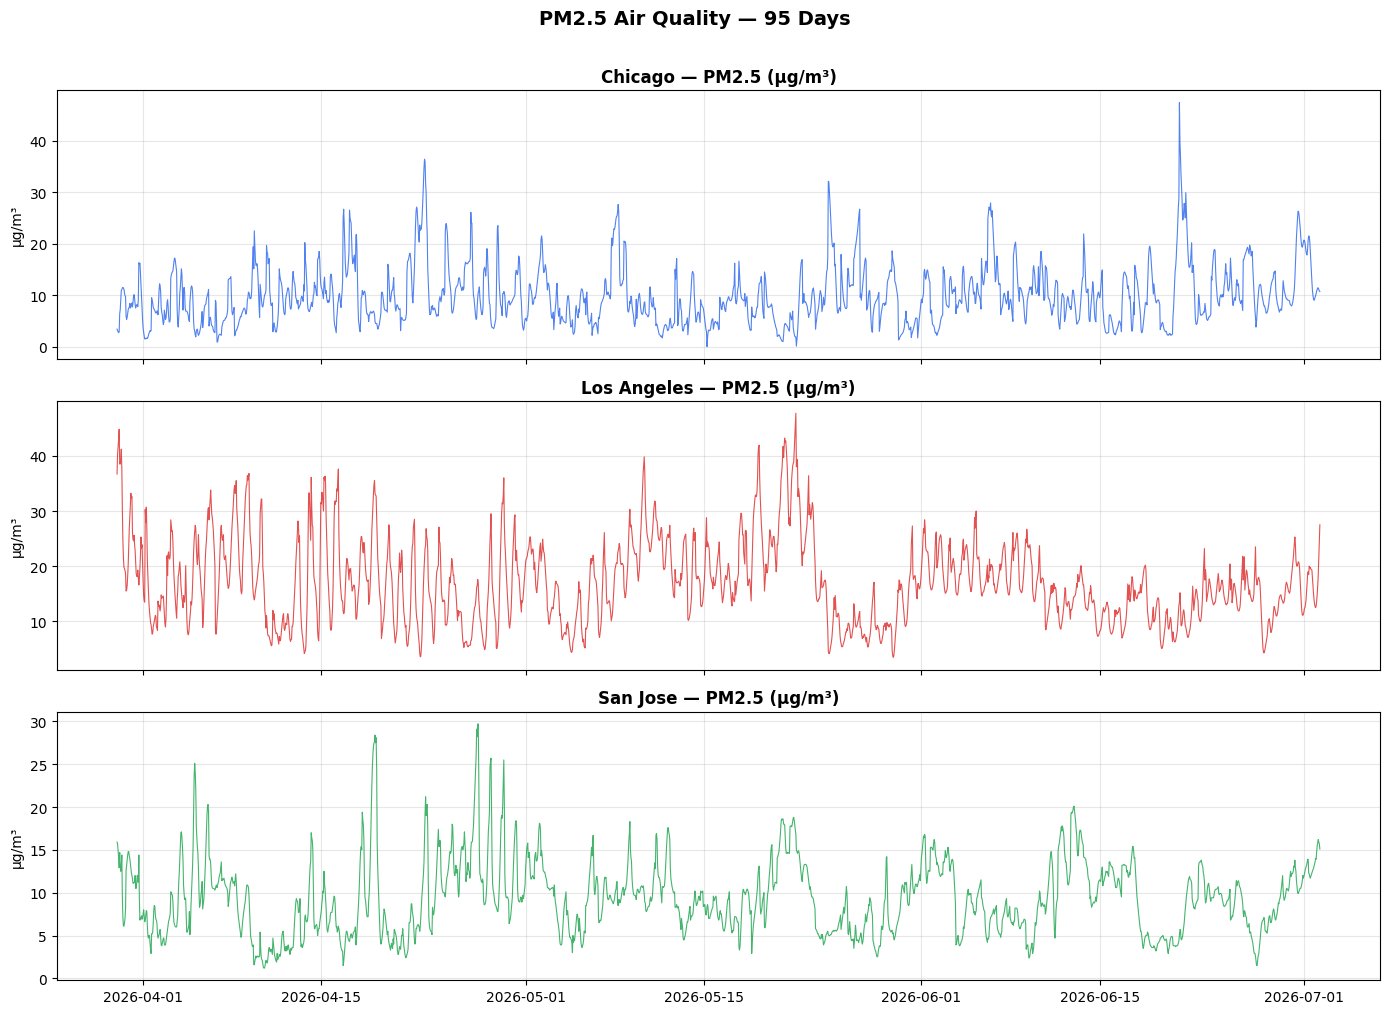

In [90]:
# Plotting PM2.5 values by timestamp for each city

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

cities = ["Chicago", "Los Angeles", "San Jose"]
colors = ["#2563EB", "#DC2626", "#16A34A"]

for ax, city, color in zip(axes, cities, colors):
    city_df = df[df["city"] == city].set_index("timestamp")
    
    ax.plot(city_df.index, city_df["value"], 
            color=color, linewidth=0.8, alpha=0.8)
    ax.set_title(f"{city} — PM2.5 (µg/m³)", fontsize=12, fontweight="bold")
    ax.set_ylabel("µg/m³")
    ax.grid(True, alpha=0.3)

plt.suptitle("PM2.5 Air Quality — 95 Days", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

- Chicago seems to be stable mostly, around 10 but there are some spikes (anomalies) post 2026/06 touching over 35
- LA seems volatile, which might be cyclical and average and volatility dropping in June26, and a downward trade from April to June
- SJ seems stable enough with some spikes, with some spikes in April and May, but  not as much in June

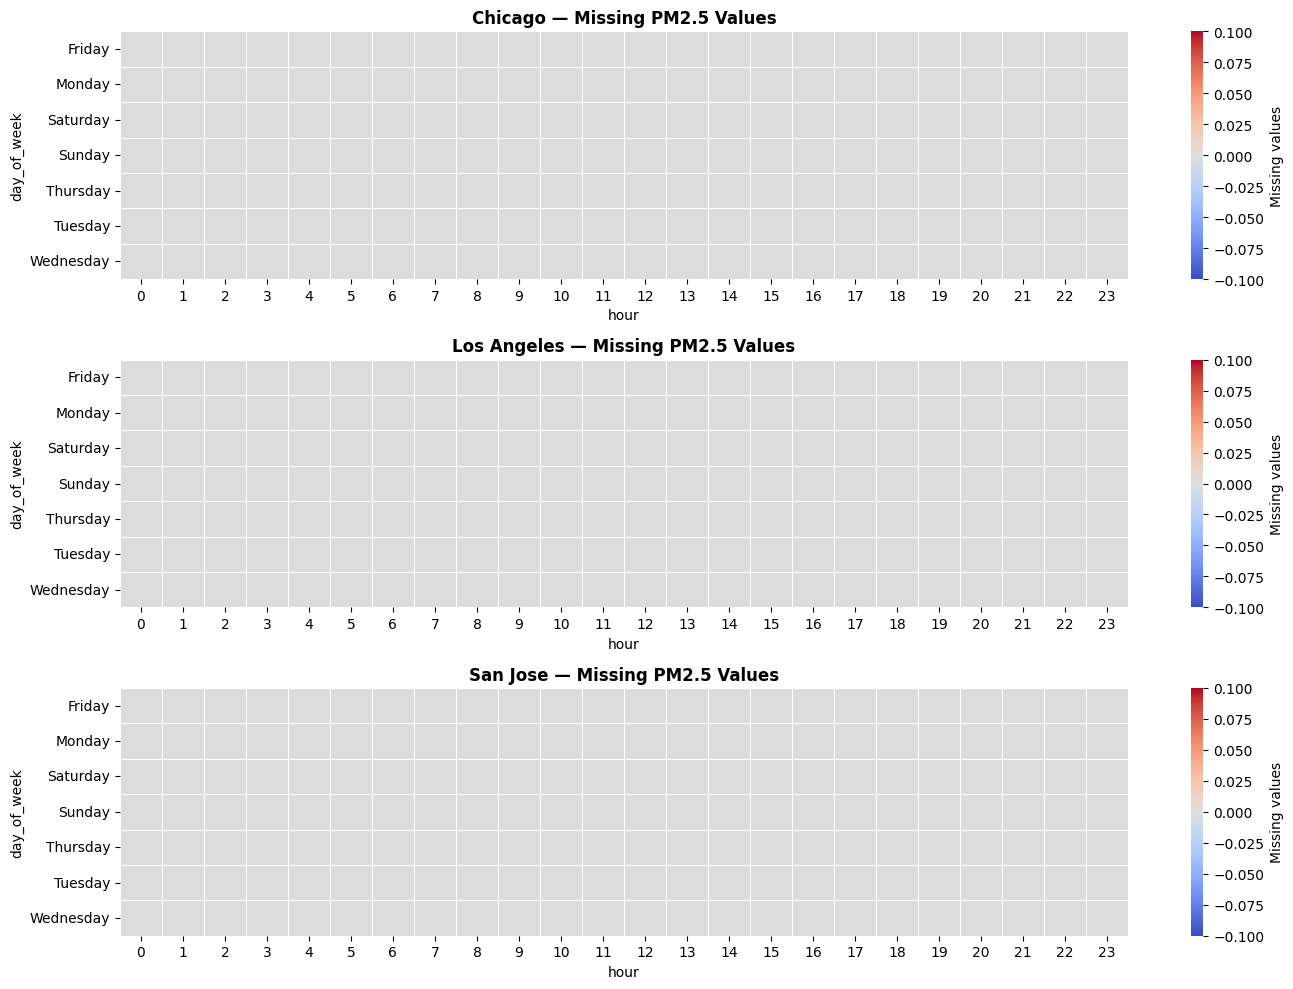

In [91]:
# Plotting heatmaps of missing PM2.5 values by hour of day and day of week for each city

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, city in zip(axes, cities):
    city_data = df[df['city'] == city].copy()
    city_data['day_of_week'] = city_data['timestamp'].dt.day_name()
    city_data['hour'] = city_data['timestamp'].dt.hour
    city_data['is_null'] = city_data['value'].isnull()
    
    df_pivot = city_data.pivot_table(index='day_of_week', columns='hour', values='is_null', aggfunc='sum')
    
    sns.heatmap(df_pivot, cmap='coolwarm', annot=False, fmt=".1f", linewidths=.5, ax=ax, cbar_kws={'label': 'Missing values'})
    ax.set_title(f"{city} — Missing PM2.5 Values", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

- There seems to  be no missing data for any of the 3 cities. cleaner.py worked well and imputed missing values correctly.

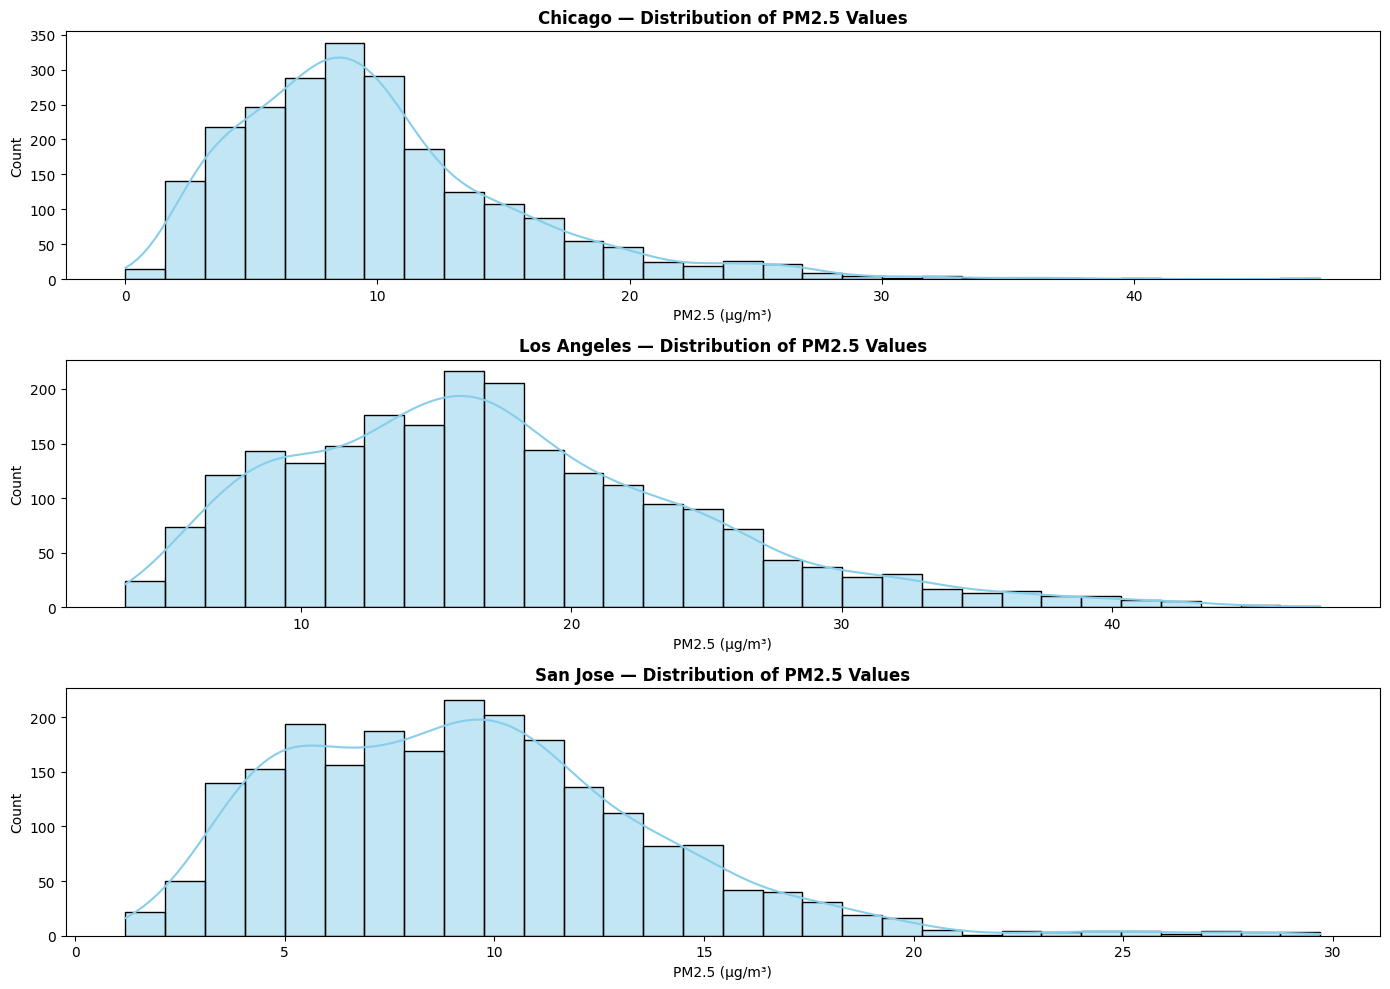

In [92]:
# Distribution of PM2.5 values for each city

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, city in zip(axes, cities):
    city_data = df[df['city'] == city].copy()
    sns.histplot(city_data['value'], bins=30, kde=True, ax=ax, color='skyblue')
    ax.set_title(f"{city} — Distribution of PM2.5 Values", fontsize=12, fontweight="bold")
    ax.set_xlabel("PM2.5 (µg/m³)")

### Alternatively can also do: (if we don't care about specific cities and want to do it for all)
# for (city, city_df), ax in zip(df.groupby("city"), axes):
#     sns.histplot(city_df["value"], ax=ax, kde=True)


plt.tight_layout()
plt.show()



- All 3 cities are clearly right skewed (long tails on right)
- Maybe the  underlaying distribution is lognormal and not normal
- So, better to do a transformation (log specifically) before SARIMA and back transform forecasts

In [93]:
# Stationarity Tests
# Directly can run ADFuller or KPSS as they internally use their own lag selection methods.
# But we can also use ACF and PACF plots to get p and q values for ARIMA model before running the tests

for (city, city_df), ax in zip(df.groupby("city"), axes):
    city_df = city_df.set_index("timestamp")
    adf_result = stattools.adfuller(city_df["value"].dropna(), autolag="AIC")
    print(f"{city}: ADF Statistic = {adf_result[0]:.6f}, p-value = {adf_result[1]:.6f}")

    kpss_result = stattools.kpss(city_df["value"].dropna(), regression="c", nlags="auto") #"c"~ constant regression, "ct"~ constant and trend regression
    print(f"{city}: KPSS Statistic = {kpss_result[0]:.6f}, p-value = {kpss_result[1]:.6f}")

    

Chicago: ADF Statistic = -11.277325, p-value = 0.000000
Chicago: KPSS Statistic = 0.313314, p-value = 0.100000
Los Angeles: ADF Statistic = -4.350022, p-value = 0.000363
Los Angeles: KPSS Statistic = 0.592547, p-value = 0.023314


C:\Users\Hanisha\AppData\Local\Temp\ipykernel_20800\672876448.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = stattools.kpss(city_df["value"].dropna(), regression="c", nlags="auto") #"c"~ constant regression, "ct"~ constant and trend regression


San Jose: ADF Statistic = -5.405219, p-value = 0.000003
San Jose: KPSS Statistic = 0.092274, p-value = 0.100000


C:\Users\Hanisha\AppData\Local\Temp\ipykernel_20800\672876448.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = stattools.kpss(city_df["value"].dropna(), regression="c", nlags="auto") #"c"~ constant regression, "ct"~ constant and trend regression


- Chicago ADF p-value < 0.05, and KPSS p-value > 0.05, indicating stationarity.
- Los Angeles ADF p-value < 0.05, and KPSS p-value > 0.05, indicating stationarity.
- San Jose ADF p-value < 0.05, and KPSS p-value > 0.05, indicating stationarity.

All the time series are clearly stationary, hence no differencing needed. d = 0 before fitting SARIMA ✅

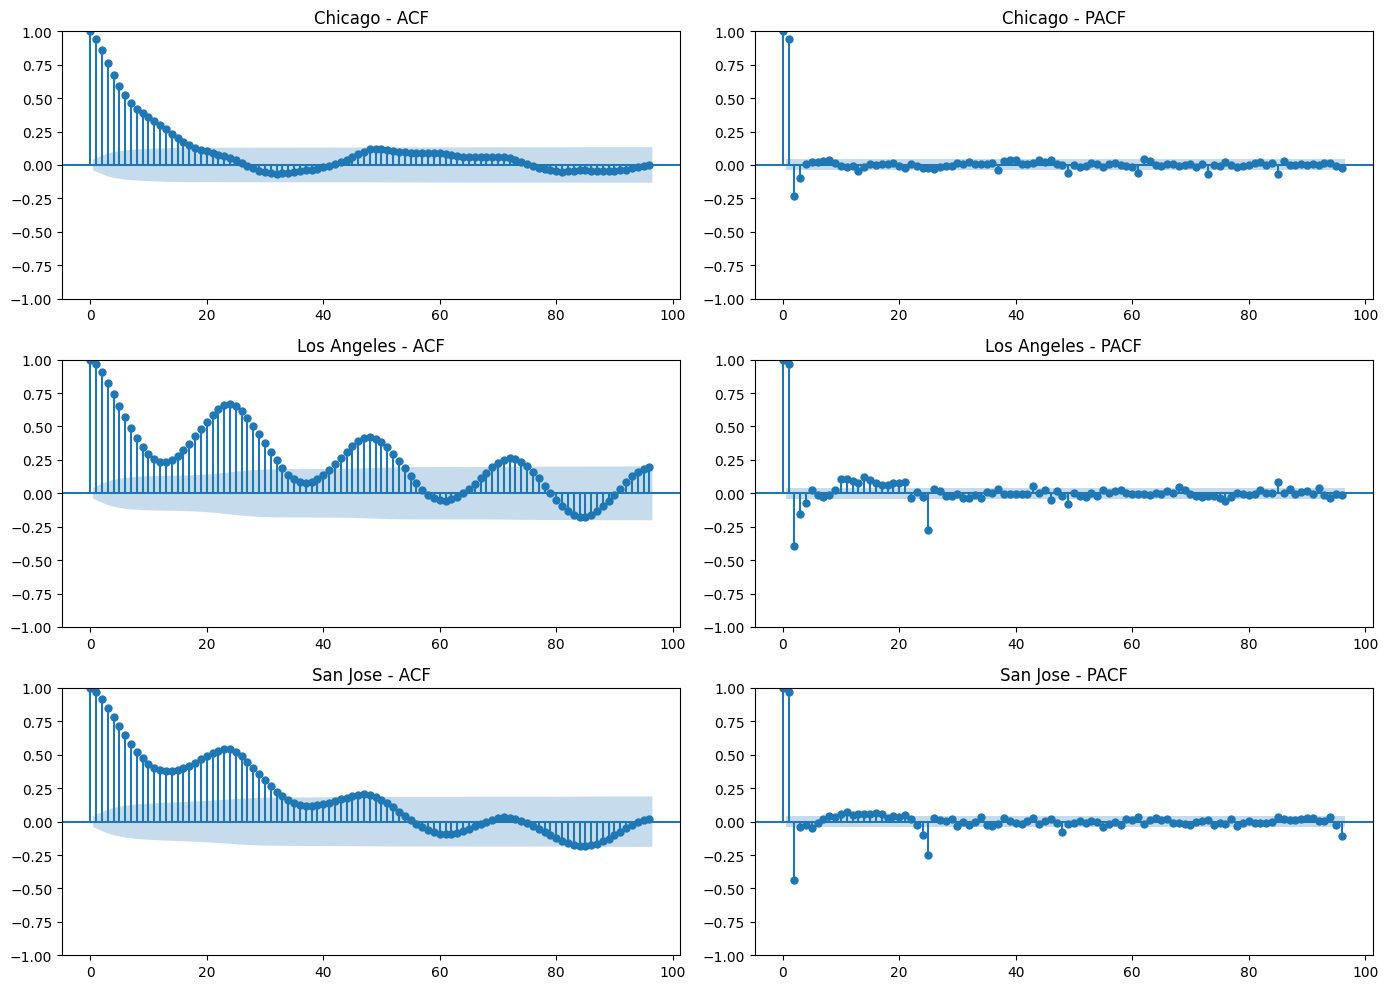

In [94]:
# ACF and PACF Plots to get p and q values for ARIMA model:

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for (city, city_df), (ax_acf, ax_pacf) in zip(df.groupby("city"), axes):
    city_df = city_df.set_index("timestamp")
    # acf = stattools.acf(city_df["value"].dropna(), nlags=20, ax=ax)
    # pacf = stattools.pacf(city_df["value"].dropna(), nlags=20, ax=ax)

    plot_acf = tsaplots.plot_acf(city_df["value"].dropna(), lags= 96, ax=ax_acf, title=f"{city} - ACF")
    plot_pacf = tsaplots.plot_pacf(city_df["value"].dropna(), lags=96, ax=ax_pacf, title=f"{city} - PACF")

plt.tight_layout()
plt.show()


- LA and San Jose, ACF going down and PACF cut off at p =2. Hence, it is AR(2) process. But for these two cities, we see that there's a dip at 12 hours and rise again at 24. So, there seems to be some seasonal cycle as well.

- Chicago, ACF decays slowly and PACF cut off at p =1. Hence, it is AR(1) process. But upon careful consideration, we can see that there is a 24 hour cycle repearing even there, but not as much. Depending on how much data we've, we can decide the complexity of the model as models become slower as we increase the seasonality, and if the intraday pattern is not significant.

- So, maybe for the models, use weekly data for modeling Chicago's seasonality and hourly data for other two cities.


In [95]:
## Resampling to daily frequency and calculating mean PM2.5 values for Chicago
chicago_daily = (df[df["city"] == "Chicago"]
           .set_index("timestamp")
           .resample("D")
           .agg({
               "value": "mean",
               "is_outlier_flag": "max"  # True if any hour that day was flagged
           })
           .reset_index())

chicago_daily["city"] = "Chicago"
print(chicago_daily.head())
print(f"Chicago daily rows: {len(chicago_daily)}")

chicago_daily = chicago_daily.set_index("timestamp")

   timestamp      value  is_outlier_flag     city
0 2026-03-30   7.529167                0  Chicago
1 2026-03-31   9.791667                0  Chicago
2 2026-04-01   4.083333                0  Chicago
3 2026-04-02   7.379167                0  Chicago
4 2026-04-03  10.950000                0  Chicago
Chicago daily rows: 95


In [96]:
# Resampling to hourly frequency and calculating mean PM2.5 values for Los Angeles and San Jose

la_hourly = (df[df["city"] == "Los Angeles"]
            .set_index("timestamp")
            .resample("h")
            .agg({
               "value": "mean",
               "is_outlier_flag": "max"  # True if any hour that day was flagged
           })
            .reset_index())

la_hourly["city"] = "Los Angeles"
print(la_hourly.head())
print(f"Los Angeles hourly rows: {len(la_hourly)}")

la_hourly = la_hourly.set_index("timestamp")

sj_hourly = (df[df["city"] == "San Jose"]
            .set_index("timestamp")
            .resample("h")
            .agg({
               "value": "mean",
               "is_outlier_flag": "max"  # True if any hour that day was flagged
           })
            .reset_index())

sj_hourly["city"] = "San Jose"
print(sj_hourly.head())
print(f"San Jose hourly rows: {len(sj_hourly)}")

sj_hourly = sj_hourly.set_index("timestamp")

            timestamp  value  is_outlier_flag         city
0 2026-03-30 00:00:00   36.7                0  Los Angeles
1 2026-03-30 01:00:00   40.3                0  Los Angeles
2 2026-03-30 02:00:00   41.6                0  Los Angeles
3 2026-03-30 03:00:00   43.0                0  Los Angeles
4 2026-03-30 04:00:00   44.8                0  Los Angeles
Los Angeles hourly rows: 2262
            timestamp  value  is_outlier_flag      city
0 2026-03-30 00:00:00   15.9                0  San Jose
1 2026-03-30 01:00:00   15.7                0  San Jose
2 2026-03-30 02:00:00   14.9                0  San Jose
3 2026-03-30 03:00:00   14.1                0  San Jose
4 2026-03-30 04:00:00   12.9                0  San Jose
San Jose hourly rows: 2262


timestamp
2026-03-30    7.738325
2026-03-31    7.663876
2026-04-01    7.604531
2026-04-02    7.558387
2026-04-03    7.524216
Name: trend, dtype: float64


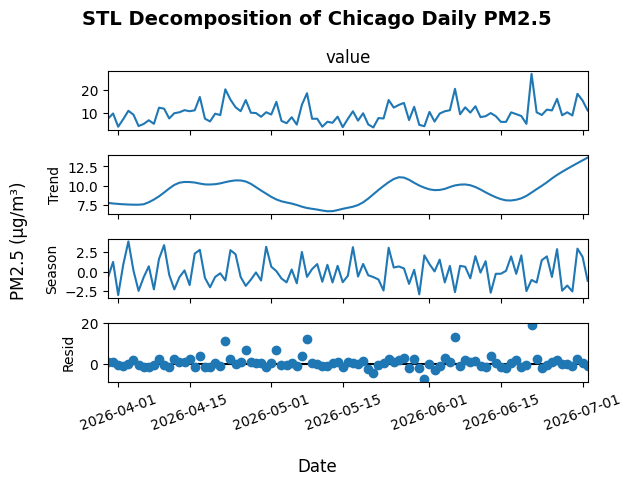

In [97]:
## STL Decomposition for Chicago daily data

stl_chicago = seasonal.STL(chicago_daily["value"].dropna(), period=7, robust=True)
result_chicago = stl_chicago.fit()
print(result_chicago.trend.head())

fig = result_chicago.plot()
fig.suptitle("STL Decomposition of Chicago Daily PM2.5", fontsize=14, fontweight="bold")
fig.supxlabel("Date")
fig.supylabel("PM2.5 (µg/m³)")
fig.axes[-1].tick_params(axis='x', rotation=20) #Flipping date labels for better visibility, and only the last subplot
plt.tight_layout()
plt.subplots_adjust
plt.show()

- Seasonal Component is small and almost stable, so it is additive in behaviour (does not correlate with trend)
- Residuals are small with few spikes, indicating anomaly events

timestamp
2026-03-30 00:00:00    32.505800
2026-03-30 01:00:00    32.162145
2026-03-30 02:00:00    31.820218
2026-03-30 03:00:00    31.480155
2026-03-30 04:00:00    31.142095
Name: trend, dtype: float64


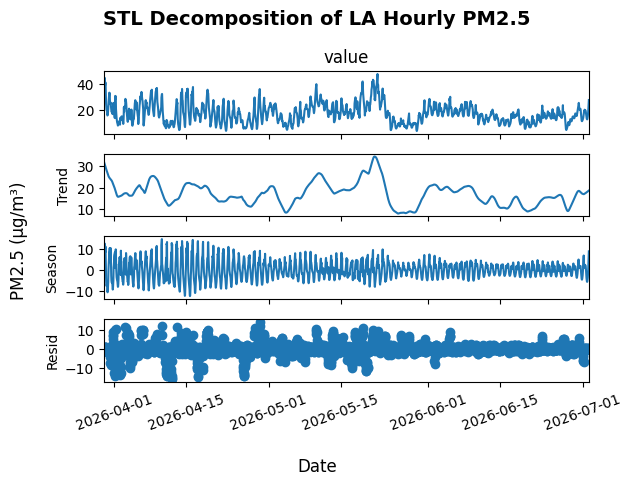

In [98]:
## STL Decomposition for LA hourly data
stl_la = seasonal.STL(la_hourly["value"].dropna(), period=24, robust=True)
result_la = stl_la.fit()
print(result_la.trend.head())

fig = result_la.plot()
fig.suptitle("STL Decomposition of LA Hourly PM2.5", fontsize=14, fontweight="bold")
fig.supxlabel("Date")
fig.supylabel("PM2.5 (µg/m³)")
fig.axes[-1].tick_params(axis='x', rotation=20) #Flipping date labels for better visibility, and only the last subplot
plt.tight_layout()
plt.subplots_adjust
plt.show()

- Trend suddenly goes down in the middle of May, then recovers ~ Investigate what happened then to assign a reason
- Seasonality amplitude is large, and seems to shrink as trend dropped. Hence, it is multiplicative in behavior
- Residuals are noisy

timestamp
2026-03-30 00:00:00    13.897834
2026-03-30 01:00:00    13.807386
2026-03-30 02:00:00    13.717158
2026-03-30 03:00:00    13.627123
2026-03-30 04:00:00    13.537230
Name: trend, dtype: float64


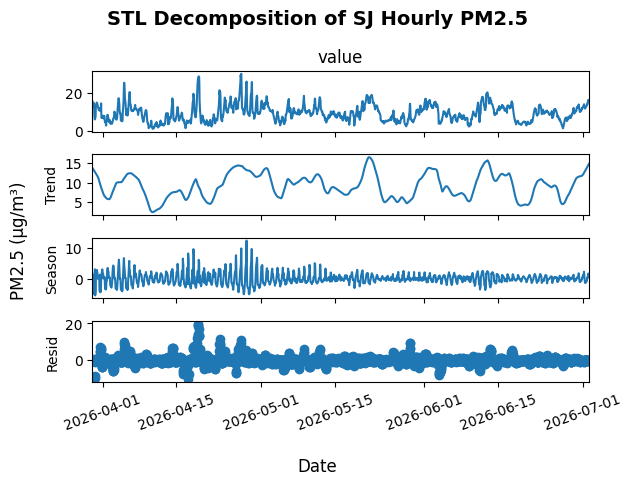

In [99]:
## STL Decomposition for San Jose hourly data
stl_sj = seasonal.STL(sj_hourly["value"].dropna(), period=24, robust=True)
result_sj = stl_sj.fit()
print(result_sj.trend.head())

fig = result_sj.plot()
fig.suptitle("STL Decomposition of SJ Hourly PM2.5", fontsize=14, fontweight="bold")
fig.supxlabel("Date")
fig.supylabel("PM2.5 (µg/m³)")
fig.axes[-1].tick_params(axis='x', rotation=20) #Flipping date labels for better visibility, and only the last subplot
plt.tight_layout()
plt.subplots_adjust
plt.show()

- No clear direction in trend
- Seasonality seems high when trend is large, small when trend is low. Hence, multiplicative in nature
- Residuals are mostly clean

In [100]:
city_df = df[df["city"] == city].set_index("timestamp").resample("D")["value"].mean().reset_index()
city_df.head()

,timestamp,value
0,2026-03-30,12.070833
1,2026-03-31,10.766667
2,2026-04-01,6.233333
3,2026-04-02,5.029167
4,2026-04-03,8.520833


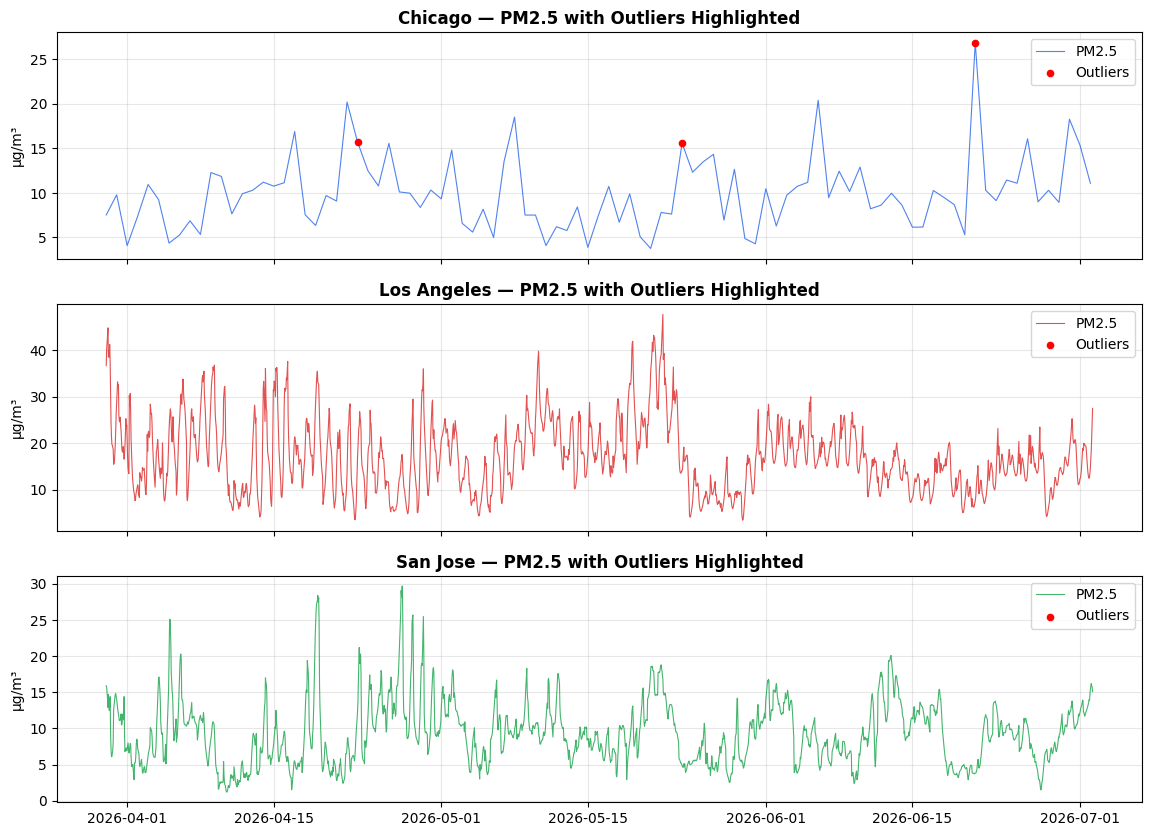

In [101]:
# Anomaly Visualization: Plotting PM2.5 values with outliers highlighted for each city

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, city, color in zip(axes, cities, colors):
    if city == "Chicago":
        city_df = chicago_daily
    elif city == "Los Angeles":
        city_df = la_hourly
    elif city == "San Jose":
        city_df = sj_hourly
    
    ax.plot(city_df.index, city_df["value"], 
            color=color, linewidth=0.8, alpha=0.8, label="PM2.5")
    
    # Highlight outliers
    outliers = city_df[city_df["is_outlier_flag"] == 1]
    ax.scatter(outliers.index, outliers["value"], color='red', s=20, label="Outliers", zorder=5)
    
    ax.set_title(f"{city} — PM2.5 with Outliers Highlighted", fontsize=12, fontweight="bold")
    ax.set_ylabel("µg/m³")
    ax.grid(True, alpha=0.3)
    ax.legend()



- 3 days have been flagged as anomalies in Chicago but none for SJ and LA
- This could be because on an avg, Chicago's variability is low and even small deviations can be marked as outlier unlike for LA and SJ, where the threshold is way higher and not easily triggered

#### SUMMARY:
- All 3 series don't need differencing, d = 0.
- Chicago shows weekly seasonal data, and seasonality is additive in nature ~ Use daily data
- LA and SJ strongly show 24 hour daily cycle, and seasonality is multiplicative in nature ~ Use hourly data
- Distributions are right skewed, and consistent with log normal distribution
- No anomalies for LA and SJ, but Chicago has 3 anomaly days
